# Example of usage of waveguide code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
R = 2.
H = 1.

NGSOLVE = True

lc = 0.3

# if NGSOLVE:
#     from cases.waveguide.ngsolve_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbosity=0, lc=lc)
# else:
#     from cases.waveguide.gmsh_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbose=True, lc=lc)


In [2]:
from cases.waveguide.base import CleanWaveguide

waveguide = CleanWaveguide(R=R, H=H, lc=lc)

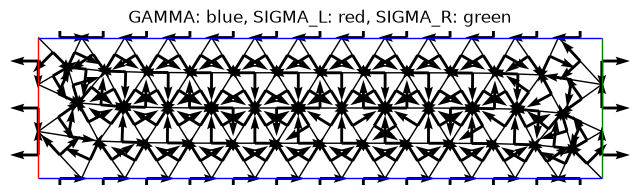

In [3]:
waveguide.plot()

In [4]:
list(waveguide.mesh.boundary_regions)

[<BoundaryRegions.GAMMA: 'Gamma'>,
 <BoundaryRegions.SIGMA_L: 'Sigma_L'>,
 <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

To that regions we can apply different boundary conditions. In our case we will set a radianting boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [5]:
from trefftz.dg.boundary_conditions import SoundHardBC, NtDBC

In [6]:
boundary_conditions = {waveguide.mesh.boundary_regions.GAMMA: SoundHardBC(),
                       waveguide.mesh.boundary_regions.SIGMA_L: NtDBC(truncating_radius=R, data=1.), #I need to refine this, right now "data" is nonsense
                       waveguide.mesh.boundary_regions.SIGMA_R: NtDBC(truncating_radius=R, data=1.)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [7]:
from trefftz.dg.serial_kernels import NeumannKernel, UltraWeakKernel


as well as specific ones (for the waveguide):

In [8]:
from cases.waveguide.kernels import NtD_nonlocal, NtDLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [9]:
from trefftz.dg.assemblers import SerialNumerics
n = 0
numerics = SerialNumerics(interior_kernel=UltraWeakKernel(a=0.5, b=0.5),
                          local_boundary_kernels={SoundHardBC: NeumannKernel(d_1=0.5),
                                                  NtDBC: NtDLocal(R=R, d_2=0.5, n=n, H=H)},
                          nonlocal_boundary_kernels={NtDBC: NtD_nonlocal(R=R, d_2=0.5, M=10, H=H)})

We should also choose a local basis

In [10]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
basis = LinearlySpacedBasis(N_elements=waveguide.mesh.n_triangles, k=k, N_theta=3)

and an assembler:

In [11]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=waveguide.mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

so we can set the problem:

In [12]:
from trefftz.problem import Problem  # (I don't think "problem" uses "numerics" any more.)
P = Problem(mesh=waveguide.mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=False)  #, numerics=numerics)

In [13]:
A = P.assemble_LHS()

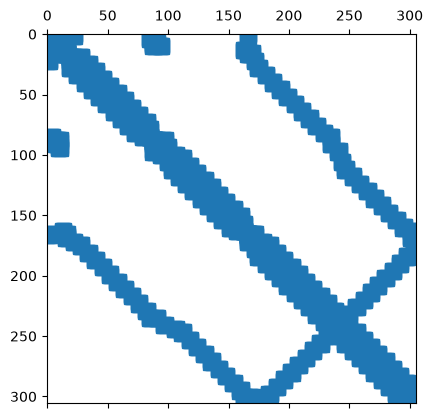

In [14]:
import matplotlib.pyplot as plt 
plt.spy(A)

In [15]:
b = P.assemble_RHS()

In [16]:
P.solve()

In [17]:
P.u_h.coefficients.reshape((-1,3))

array([[ 1.00180128e+00+4.10041858e-03j,  1.47410886e-01+1.85054613e-01j,
         3.03432929e-02+7.11645336e-02j],
       [ 1.19643474e+00+2.89765259e-02j,  5.54195263e-01-1.05856652e-01j,
         6.89087135e-01-2.94457110e-02j],
       [ 7.75290795e-01+1.48855826e-01j, -3.92058521e-01-6.41873878e-01j,
         6.03095839e-01+1.17431830e-01j],
       [ 6.98576864e-01+2.42425732e-01j,  7.36090435e-01-3.10062267e-01j,
         1.38794264e-01-3.56130029e-01j],
       [ 9.93119942e-01-1.51393239e-02j,  9.24046484e-02+1.74449683e-02j,
         9.78443740e-03+7.86674851e-02j],
       [ 9.81818397e-01+5.71548686e-03j,  9.51231379e-02+6.96792480e-02j,
         3.47600570e-02+2.26471585e-01j],
       [ 9.93040608e-01-7.54633118e-03j,  6.50724199e-02+1.32940734e-02j,
         6.37329915e-02+1.82958374e-02j],
       [ 1.00505793e+00-3.40157990e-03j,  1.05510108e-01+7.83860668e-02j,
         4.92027492e-02-1.51126902e-02j],
       [ 9.93820695e-01-1.54131489e-02j,  7.30816508e-02-3.80975871e-03j

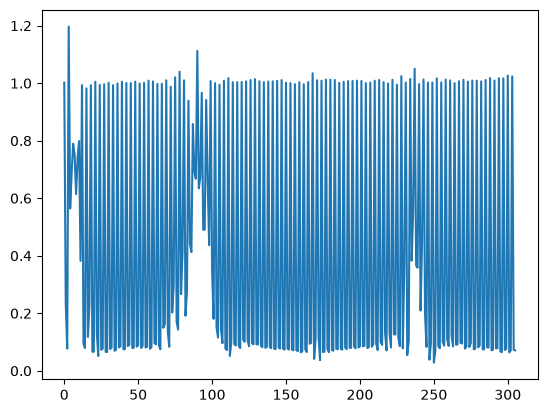

In [18]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [19]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(0., H, int(N*H/R))
X, Y = np.meshgrid(x, y)
Z = P.u_h(X.ravel(), Y.ravel()).reshape(X.shape)

(0.0, 1.0)

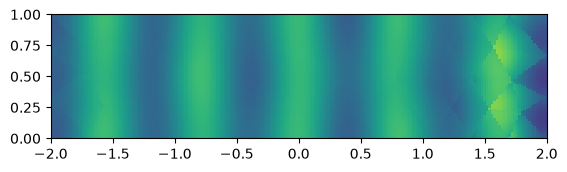

In [20]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real, vmin=-3, vmax=3)
plt.axis('square')
plt.xlim([-R, R])
plt.ylim([0., H])